In [1]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error
import optuna

/Users/noah/repos/Icequake-QRC-/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known, scaler_X, scaler_y = preprocess_data(filtered_time, data_orig)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(4941, 3)
(4941, 8)
(5150, 8)
1       78360.0
2       38730.0
3       47715.0
4       68805.0
5       82695.0
         ...   
3045    86310.0
3046    59085.0
3047    33915.0
3048    59280.0
3049    35265.0
Name: time_to_next_ev_hr, Length: 2964, dtype: float64
   tide_deriv  form_fac  slip_size  high_t_evt  tide_height  time_since
1    0.056003  1.826057  -1.811724           1    33.714046     61950.0
2   -0.032735  1.560612  -1.110816           1     5.033164     78165.0
3   -0.056060  1.590570  -2.703974           0   -35.730665     39015.0
4   -0.121354  1.590570  -1.704758           0    -3.994414     47850.0
5   -0.012976  2.166519  -1.519707           1    21.697819     72015.0


In [ ]:
# XGBoost

#Tuning XGBoost through the Optuna library
def objective(trial):
  XGBoost = XGBRegressor(
      objective="reg:squarederror",
      n_estimators=1000,
      learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True), #sweeping 0.01 to 0.1 in the log scale for optimal learning rate
      max_depth=trial.suggest_int("max_depth",2,5), #checking max depth between 2 and 5
      subsample=trial.suggest_float("subsample",0.6,0.9), #sweeping subsample possibilites between 0.6 and 0.9
      colsample_bytree=trial.suggest_float("colsample_bytree",0.6,0.9), #sweeping bytree parameters between 0.6 and 0.9
      random_state=42
  )
  XGBoost.fit(
      X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) #To see more model info set verbose=True
  predictions= XGBoost.predict(X_val)
  RMSE = root_mean_squared_error(y_val, predictions)
  return RMSE

sampler = optuna.samplers.TPESampler(seed=42)  # Fix seed for reproducibility
optimization = optuna.create_study(direction="minimize", sampler=sampler) #Finding the parameters that minimize the MAE
optimization.optimize(objective, n_trials=30) #Keeping at 30 to prevent overfitting with noise

#Showing what the parameters are
optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

#Running the XGBoost with the optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

#Calculating error for XGBoost - unscale predictions and test values back to original seconds
XGBoost_Prediction_scaled = XGBoost.predict(X_test)
XGBoost_Prediction = scaler_y.inverse_transform(XGBoost_Prediction_scaled.reshape(-1, 1)).flatten()
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

XGBoost_RMSE = root_mean_squared_error(y_test_original, XGBoost_Prediction)
XGBoost_Error = XGBoost_RMSE
print("XGBoost RMSE (seconds):", XGBoost_Error)

XGBoost_MAE = mean_absolute_error(y_test_original, XGBoost_Prediction)
print("XGBoost MAE (seconds):", XGBoost_MAE)

Sample0: True = 83970.00s, Predicted = 68433.61s, Error=15536.39s
Sample1: True = 87270.00s, Predicted = 34305.23s, Error=52964.77s
Sample2: True = 33150.00s, Predicted = 30898.82s, Error=2251.18s
Sample3: True = 63240.00s, Predicted = 60911.80s, Error=2328.20s
Sample4: True = 83475.00s, Predicted = 77128.28s, Error=6346.72s
Sample5: True = 30930.00s, Predicted = 27483.19s, Error=3446.81s
Sample6: True = 64215.00s, Predicted = 60866.39s, Error=3348.61s
Sample7: True = 80820.00s, Predicted = 61342.60s, Error=19477.40s
Sample8: True = 29430.00s, Predicted = 53137.71s, Error=23707.71s
Sample9: True = 57720.00s, Predicted = 55638.41s, Error=2081.59s
Sample10: True = 86460.00s, Predicted = 51377.46s, Error=35082.54s
Sample11: True = 40245.00s, Predicted = 59445.97s, Error=19200.97s
Sample12: True = 48015.00s, Predicted = 56292.83s, Error=8277.83s
Sample13: True = 84210.00s, Predicted = 53050.97s, Error=31159.03s
Sample14: True = 51780.00s, Predicted = 50744.97s, Error=1035.03s
Sample15: Tru

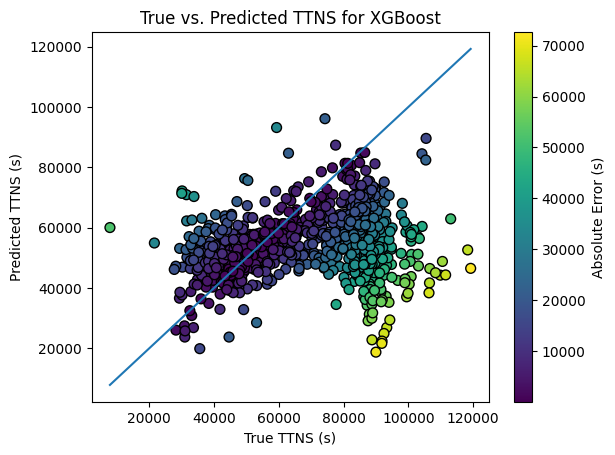

In [4]:
#XGBoost Analysis

# Values are already unscaled from the previous cell
y_test_secs = y_test_original
XG_pred_secs = XGBoost_Prediction

absolute_error_secs_XG = np.abs(XG_pred_secs - y_test_secs)

#printing the true vs predicted value and error in seconds for every record
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, XG_pred_secs, absolute_error_secs_XG)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, XG_pred_secs, c=absolute_error_secs_XG, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for XGBoost")
plt.show()

XG Boost Drivers: form_fac       0.180630
time_since     0.144046
tide_deriv     0.141427
tide_height    0.140841
slip_size      0.112346
high_t_evt     0.005916
dtype: float64


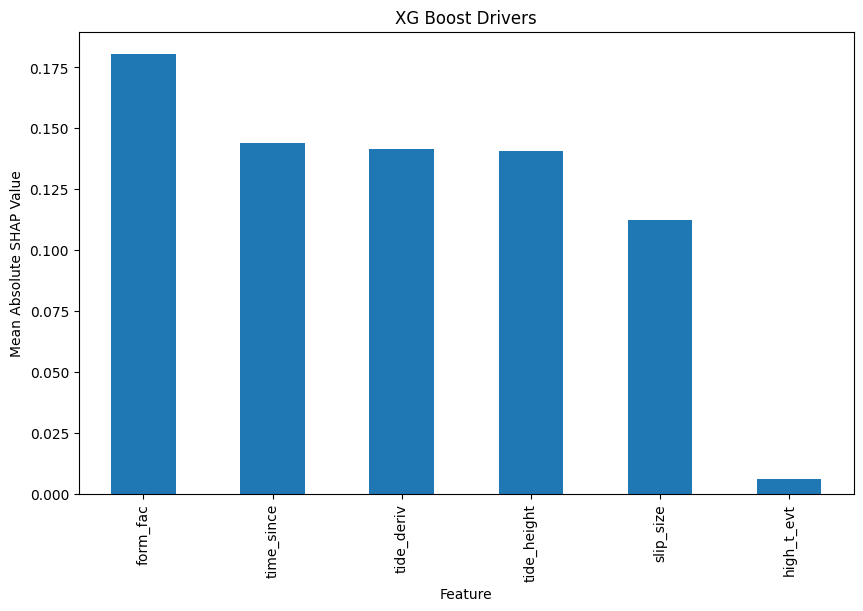

In [5]:
# Driving parameters for XG 

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
explainer_XG = shap.TreeExplainer(XGBoost, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_XG = explainer_XG.shap_values(X_shap) #Doing the tree analysis on XG using training data

XG_imp = pd.Series(np.abs(shap_values_XG).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in XG

print("XG Boost Drivers:", XG_imp)

# Creating a bar graph showing the driving parameters for XGBoost 
plt.figure(figsize=(10, 6))
XG_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("XG Boost Drivers")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()
